# ENSO from ModE-Sim MME vs Cook 2024 reconstruction

Uses all 10 ModE-Sim members (set_1420-3, m041–m050) from three tar archives,
extracts the NINO3.4 region (5°S–5°N, 170°W–120°W), computes an annual
multi-model ensemble mean (MME) DJF NINO3.4 anomaly, and compares with the
Cook 2024 reconstruction used in the famine dataset.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr
import tarfile
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         12,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'pdf.fonttype':      42,
})

## 1. Extract ModE-Sim SST members

In [2]:
TARS = {
    '../data/ModE-Sim_s14203_forc_1-3.tar':   ['m041', 'm042', 'm043'],
    '../data/ModE-Sim_s14203_forc_4-6.tar':   ['m044', 'm045', 'm046'],
    '../data/ModE-Sim_s14203_forc_7-10.tar':  ['m047', 'm048', 'm049', 'm050'],
    '../data/ModE-Sim_s14203_forc_11-14.tar': ['m051', 'm052', 'm053', 'm054'],
    '../data/ModE-Sim_s14203_forc_15-18.tar': ['m055', 'm056', 'm057', 'm058'],
    '../data/ModE-Sim_s14203_forc_19-20.tar': ['m059', 'm060'],
}
CACHE_DIR   = '../data/modesim_cache'
nc_pattern  = 'ModE-Sim_set_1420-3_{member}_sst_abs_1380-1849_mon.nc'
os.makedirs(CACHE_DIR, exist_ok=True)

# Extract all members from all tars (skip if already cached)
for tar_path, members in TARS.items():
    with tarfile.open(tar_path) as tf:
        for member in members:
            fname = nc_pattern.format(member=member)
            dest  = os.path.join(CACHE_DIR, fname)
            if not os.path.exists(dest):
                print(f'Extracting {fname} from {os.path.basename(tar_path)}...')
                tf.extract(fname, path=CACHE_DIR)
            else:
                print(f'Cached: {fname}')

ALL_MEMBERS = [m for members in TARS.values() for m in members]
print(f'\nAll {len(ALL_MEMBERS)} members ready: {ALL_MEMBERS}')

Cached: ModE-Sim_set_1420-3_m041_sst_abs_1380-1849_mon.nc
Cached: ModE-Sim_set_1420-3_m042_sst_abs_1380-1849_mon.nc
Cached: ModE-Sim_set_1420-3_m043_sst_abs_1380-1849_mon.nc
Cached: ModE-Sim_set_1420-3_m044_sst_abs_1380-1849_mon.nc
Cached: ModE-Sim_set_1420-3_m045_sst_abs_1380-1849_mon.nc
Cached: ModE-Sim_set_1420-3_m046_sst_abs_1380-1849_mon.nc
Cached: ModE-Sim_set_1420-3_m047_sst_abs_1380-1849_mon.nc
Cached: ModE-Sim_set_1420-3_m048_sst_abs_1380-1849_mon.nc
Cached: ModE-Sim_set_1420-3_m049_sst_abs_1380-1849_mon.nc
Cached: ModE-Sim_set_1420-3_m050_sst_abs_1380-1849_mon.nc
Cached: ModE-Sim_set_1420-3_m051_sst_abs_1380-1849_mon.nc
Cached: ModE-Sim_set_1420-3_m052_sst_abs_1380-1849_mon.nc
Cached: ModE-Sim_set_1420-3_m053_sst_abs_1380-1849_mon.nc
Cached: ModE-Sim_set_1420-3_m054_sst_abs_1380-1849_mon.nc
Cached: ModE-Sim_set_1420-3_m055_sst_abs_1380-1849_mon.nc
Cached: ModE-Sim_set_1420-3_m056_sst_abs_1380-1849_mon.nc
Cached: ModE-Sim_set_1420-3_m057_sst_abs_1380-1849_mon.nc
Cached: ModE-S

## 2. Compute ensemble-mean DJF NINO3.4 anomaly

NINO3.4 box: 5°S–5°N, 170°W–120°W = lon 190°–240° in 0–360°.  
DJF = December(year-1) + January + February, assigned to the year of Jan–Feb.  
ModE-Sim lat is descending (Gaussian T63): slice(5, -5) selects 5°N → 5°S.

In [ ]:
CLIM_START, CLIM_END = 1800, 1849
SERIES_START, SERIES_END = 1500, 1800

def nino34_djf(nc_path):
    """Return full DJF NINO3.4 series for one ModE-Sim member.

    ModE-Sim SST: variable 'sst', units K, lon 0–360°, lat descending (Gaussian T63).
    NINO3.4 box: 5°S–5°N, 190°–240° → slice(5, -5) for descending lat.
    """
    ds  = xr.open_dataset(nc_path, use_cftime=True)
    sst = ds['sst'] - 273.15                          # K → °C
    box = sst.sel(lat=slice(5, -5), lon=slice(190, 240))
    weights  = np.cos(np.deg2rad(box['lat'].values))

    weights /= weights.sum()
    nino_mon = (box.values * weights[np.newaxis, :, np.newaxis]).sum(axis=1).mean(axis=1)
    nino_mon = xr.DataArray(nino_mon, coords={'time': box['time']}, dims='time')
    box.close(); ds.close()

    new_times = [t.replace(year=t.year + 1) if t.month == 12 else t
                 for t in nino_mon['time'].values]
    nino_sh = nino_mon.assign_coords(time=new_times)
    djf = (nino_sh
           .sel(time=nino_sh.time.dt.month.isin([12, 1, 2]))
           .groupby('time.year').mean('time')
           .rename({'year': 'Year'})
           .to_series())
    return djf


member_series = []
for member in ALL_MEMBERS:
    fname = nc_pattern.format(member=member)
    path  = os.path.join(CACHE_DIR, fname)
    member_series.append(nino34_djf(path))
    print(f'Loaded {member}')

# MME mean across all members
enso_ens         = pd.concat(member_series, axis=1)
enso_ens.columns = ALL_MEMBERS
enso_mme         = enso_ens.mean(axis=1)
enso_mme.index.name = 'Year'

# Anomaly relative to 1800–1849 climatology
clim_mean   = enso_mme.loc[CLIM_START:CLIM_END].mean()
modesim_sst = (enso_mme - clim_mean).loc[SERIES_START:SERIES_END]

print(f'\nModE-Sim MME DJF NINO3.4 anomaly (°C)  '
      f'[{len(ALL_MEMBERS)} members, wrt {CLIM_START}–{CLIM_END}]:')
print(modesim_sst.describe())

Loaded m041
Loaded m042
Loaded m043
Loaded m044
Loaded m045
Loaded m046
Loaded m047
Loaded m048
Loaded m049
Loaded m050
Loaded m051
Loaded m052
Loaded m053
Loaded m054
Loaded m055
Loaded m056
Loaded m057
Loaded m058
Loaded m059
Loaded m060

ModE-Sim MME DJF NINO3.4 anomaly (°C)  [20 members, wrt 1800–1849]:
count    301.000000
mean       0.289981
std        0.595036
min       -1.321870
25%       -0.090044
50%        0.287347
75%        0.708599
max        2.180934
dtype: float64


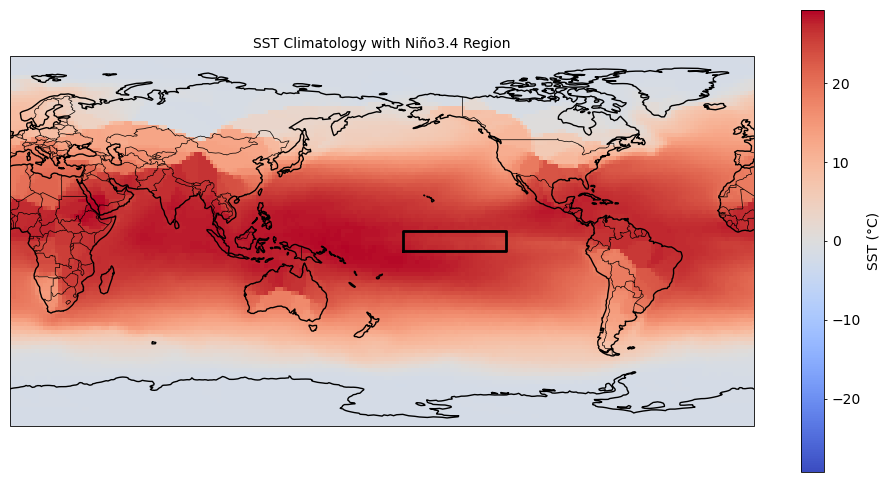

In [13]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import numpy as np

def plot_nino34_on_data(nc_path):
    ds = xr.open_dataset(nc_path, use_cftime=True)
    sst = ds['sst'] - 273.15  # °C

    # Example: climatology over your baseline period
    sst_clim = sst.sel(time=slice("1800-01-01", "1849-12-31")).mean("time")

    fig = plt.figure(figsize=(12, 6))
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

    # Plot SST field
    sst_clim.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='coolwarm',
        cbar_kwargs={'label': 'SST (°C)'}
    )

    # Add coastlines
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    # Niño3.4 box
    lon_min, lon_max = 190, 240
    lat_min, lat_max = -5, 5

    ax.plot(
        [lon_min, lon_max, lon_max, lon_min, lon_min],
        [lat_min, lat_min, lat_max, lat_max, lat_min],
        color='black',
        linewidth=2,
        transform=ccrs.PlateCarree()
    )

    ax.set_title("SST Climatology with Niño3.4 Region")
    plt.show()

    ds.close()

# call on one member
plot_nino34_on_data(path)

## 3. Load Cook 2024 NINO3.4 from famine data

In [10]:
famine = pd.read_csv('../processed data/famine_region_data.csv')
cook   = famine.groupby('Year')['nino34'].first().loc[1500:1800]

# Align
df = pd.DataFrame({
    'ModESim': modesim_sst,
    'Cook2024': cook,
}).dropna()

r_cook, p_cook = pearsonr(df['ModESim'], df['Cook2024'])
print(f'Pearson r = {r_cook:.3f}, p = {p_cook:.4g}, n = {len(df)}')

Pearson r = 0.001, p = 0.9818, n = 301


## 4. Compute correlations, then assemble figure (a time series, b scatter, c PDSI map)

In [11]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
from scipy.stats import pearsonr as _pearsonr

OWDA_PATH = '../data/owda.nc'
ALPHA     = 0.10
EXTENT    = [-10, 35, 36, 70]

# ── Load OWDA JJA scPDSI ──────────────────────────────────────────────────────
owda      = xr.open_dataset(OWDA_PATH)
int_years = owda['time'].values.astype(int)
owda = (owda
        .assign_coords(Year=('time', int_years))
        .swap_dims({'time': 'Year'})
        .sel(Year=slice(1500, 1800))
        .sel(lat=slice(35, 70), lon=slice(-15, 35)))

# Guarantee (Year, lat, lon) axis order
pdsi = owda['pdsi'].transpose('Year', 'lat', 'lon')

lat   = pdsi['lat'].values
lon   = pdsi['lon'].values
lon2d, lat2d = np.meshgrid(lon, lat)

# ── Align years ───────────────────────────────────────────────────────────────
common_yrs = np.intersect1d(pdsi['Year'].values.astype(int),
                             modesim_sst.index.values.astype(int))
pdsi_arr  = pdsi.sel(Year=common_yrs).values   # (n_years, n_lat, n_lon)
nino_arr  = modesim_sst.loc[common_yrs].values  # (n_years,)

assert pdsi_arr.shape[0] == nino_arr.shape[0], \
    f"Year mismatch: pdsi {pdsi_arr.shape[0]} vs nino {nino_arr.shape[0]}"
print(f'Correlating over {len(common_yrs)} years ({common_yrs[0]}–{common_yrs[-1]})')

# ── Point-wise Pearson r ──────────────────────────────────────────────────────
corr_pdsi = np.full((len(lat), len(lon)), np.nan)
pval_pdsi = np.full_like(corr_pdsi, np.nan)
for i in range(len(lat)):
    for j in range(len(lon)):
        ts   = pdsi_arr[:, i, j]
        mask = np.isfinite(ts) & np.isfinite(nino_arr)
        if mask.sum() > 10:
            rv, pv          = _pearsonr(ts[mask], nino_arr[mask])
            corr_pdsi[i, j] = rv
            pval_pdsi[i, j] = pv

print(f'r range: {np.nanmin(corr_pdsi):.3f} – {np.nanmax(corr_pdsi):.3f}')

Correlating over 301 years (1500–1800)
r range: -0.212 – 0.255


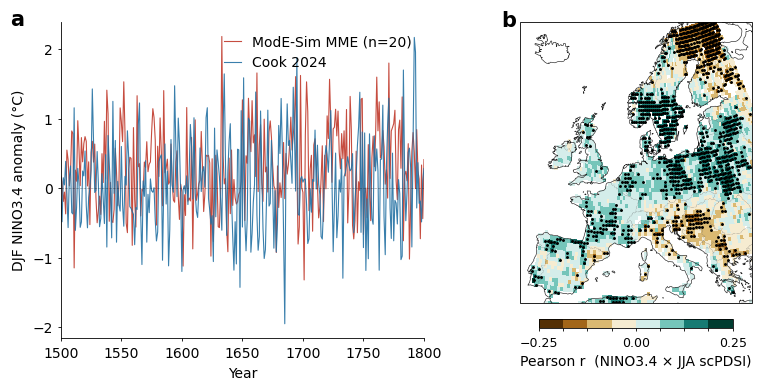

In [12]:
import matplotlib as mpl

mpl.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Helvetica', 'DejaVu Sans'],
    'font.size':         10,
    'axes.labelsize':    10,
    'axes.titlesize':    10,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'axes.linewidth':    0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.major.size':  2.5,
    'ytick.major.size':  2.5,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'pdf.fonttype':      42,
    'ps.fonttype':       42,
})

# 183 mm wide, equal columns
fig, (ax_a, ax_c) = plt.subplots(
    1, 2, figsize=(8, 4),
    gridspec_kw={'width_ratios': [1.5, 1], 'wspace': 0.3},
    subplot_kw={'projection': None},
)
ax_c.remove()
ax_c = fig.add_subplot(1, 2, 2, projection=ccrs.EuroPP())

# ── a: time series ────────────────────────────────────────────────────────────
ax_a.plot(df.index, df['ModESim'],  color='#C0392B', lw=0.8,
          label=f'ModE-Sim MME (n={len(ALL_MEMBERS)})', alpha=0.9)
ax_a.plot(df.index, df['Cook2024'], color='#2471A3', lw=0.8,
          label='Cook 2024', alpha=0.9)
ax_a.axhline(0, color='black', lw=0.5, ls='--', alpha=0.35)
ax_a.set_xlim(df.index[0], df.index[-1])
ax_a.set_xlabel('Year')
ax_a.set_ylabel('DJF NINO3.4 anomaly (°C)')
ax_a.legend(frameon=False, loc='upper right', handlelength=1.2)
# ax_a.text(0.03, 0.97,
#           f'r = {r_cook:.2f},  p = {p_cook:.3f}',
#           transform=ax_a.transAxes, fontsize=10,
#           va='top', ha='left', color='#333333')
ax_a.text(-0.14, 1.04, 'a', transform=ax_a.transAxes,
          fontsize=15, fontweight='bold', va='top')

# ── b: PDSI teleconnection map ────────────────────────────────────────────────
levels_c = np.linspace(-0.25, 0.25, 9)
cmap_c   = plt.get_cmap('BrBG', len(levels_c) - 1)
norm_c   = BoundaryNorm(levels_c, ncolors=cmap_c.N)

im = ax_c.pcolormesh(lon2d, lat2d, corr_pdsi,
                     cmap=cmap_c, norm=norm_c, shading='auto',
                     transform=ccrs.PlateCarree())
sig = pval_pdsi <= ALPHA
ax_c.scatter(lon2d[sig], lat2d[sig], s=1.2, color='black',
             transform=ccrs.PlateCarree(), zorder=5)
ax_c.coastlines(linewidth=0.45, color='#222222')
ax_c.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.35,
                 edgecolor='#555555')
ax_c.set_extent(EXTENT, crs=ccrs.PlateCarree())

cbar = plt.colorbar(im, ax=ax_c, orientation='horizontal',
                    pad=0.05, fraction=0.06, shrink=0.8, aspect=22)
cbar.set_label('Pearson r  (NINO3.4 × JJA scPDSI)', fontsize=10)
cbar.set_ticks(levels_c[::4])
cbar.ax.tick_params(labelsize=9)

ax_c.annotate('b', xy=(-0.08, 1.04), xycoords='axes fraction',
              fontsize=15, fontweight='bold', va='top')

fig.subplots_adjust(left=0.10, right=0.97, top=0.93, bottom=0.14)

out_dir = '../analysis/output/figures/extended data'
os.makedirs(out_dir, exist_ok=True)
plt.savefig(f'{out_dir}/figED_modesim_enso.pdf', dpi=300, bbox_inches='tight')
plt.show()